In [29]:
%pip install kagglehub
%pip install pandas
%pip install scipy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install statsmodels
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 6.3 MB/s eta 0:00:16
    --------------------------------------- 1.3/101.7 MB 7.5 MB/s eta 0:00:14
   - -------------------------------------- 3.7/101.7 MB 7.4 MB/s eta 0:00:14
   -- ------------------------------------- 6.0/101.7 MB 8.7 MB/s eta 0:00:12
   --- ------------------------------------ 8.7/101.7 MB 9.6 MB/s eta 0:00:10
   ---- ----------------------------------- 11.3/101.7 MB 10.1 MB/s eta 0:00:

In [2]:
import pandas
df = pandas.read_csv("dataset/games.csv")

SECTION: EXPLORATORY DATA ANALYSIS SECTION (EDA)

In [3]:
# EDA: Understanding the features of the dataset
print(df.head())
print(df.shape)
df.isnull().sum()

         id  rated    created_at  last_move_at  turns victory_status winner  \
0  TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime  white   
1  l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign  black   
2  mIICvQHh   True  1.504130e+12  1.504130e+12     61           mate  white   
3  kWKvrqYL   True  1.504110e+12  1.504110e+12     61           mate  white   
4  9tXo1AUZ   True  1.504030e+12  1.504030e+12     95           mate  white   

  increment_code       white_id  white_rating      black_id  black_rating  \
0           15+2       bourgris          1500          a-00          1191   
1           5+10           a-00          1322     skinnerua          1261   
2           5+10         ischia          1496          a-00          1500   
3           20+0  daniamurashov          1439  adivanov2009          1454   
4           30+3      nik221107          1523  adivanov2009          1469   

                                               moves opening_e

id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

In [4]:
#EDA: Visualizing the data
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import json

output_dir = "EDA"
os.makedirs(output_dir, exist_ok=True)

# Features to plot a scatterplot for
feature_plot = ['rated', 'created_at', 'last_move_at', 'turns', 'increment_code', 'black_rating', 'opening_ply']

# Scatterplot
for i in range(1, len(df.columns)):
    if df.columns[i] in feature_plot:
        filename = f'{df.columns[i]}_vs_white_rating_scatter'
        filepath = os.path.join(output_dir, filename)

        plt.figure(figsize=(12, 6))
        plt.scatter(df[df.columns[i]], df['white_rating'], alpha=0.3)
        plt.ylabel('WHITE RATING')
        plt.xlabel(df.columns[i].upper())
        plt.savefig(filepath)
        plt.close()

# Features to calculate pcc for
feature_pcc = ['rated', 'created_at', 'last_move_at', 'turns', 'black_rating', 'opening_ply']

# Format of dictionary will be:   Key = Feature | Value = [correlation coefficient, p_value]
pcc_dict = {}
# Pearson Correlation Coefficient
for column in df.columns:
    if column in feature_pcc:
        corr_co, p_value = pearsonr(df[column], df['white_rating'])
        pcc_dict[column] = (corr_co, p_value)

# Store values in a txt file
with open("EDA/pcc_values.txt", 'w') as file:
    json.dump(pcc_dict, file, indent=4)

In [5]:
# EDA: Examining increment_code feature
# Seeing if there is a relationship between increment_code and white_rating,
# but ensuring that the opening sample size is large enough to be meaningful
eco_stats = df.groupby("opening_eco")["white_rating"].agg(["mean","count"])
eco_stats_filtered = eco_stats[eco_stats["count"] > 50]
eco_stats_filtered.sort_values("mean", ascending=False).head(20)

,mean,count
opening_eco,,
B90,1772.376238,101
B13,1761.388235,85
E20,1758.454545,77
E61,1744.423729,59
A46,1741.240506,79
A15,1737.250000,60
D35,1733.069444,72
B22,1726.510638,94
B40,1713.844961,129


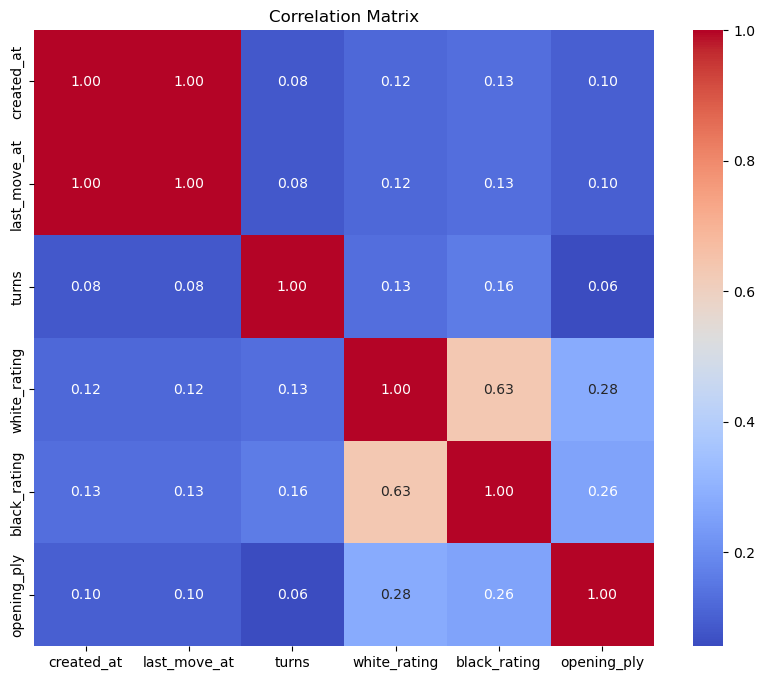

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# EDA: Correlation Matrix
numeric_df = df.select_dtypes(include=['int64','float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

SECTION: FEATURE ENGINEERING 

One thing to note is that we will be find commonly played advanced/beginner moves (e.g., pawn pushes, captures, etc.) and add them as features in the dataset. 

In [7]:
import pandas as pd

def move_features(row):
    moves = row["moves"].split()
    turns = row["turns"] / 2

    white_moves = moves[0::2]
    black_moves = moves[1::2]

    white_first5 = white_moves[:5]
    black_first5 = black_moves[:5]

    white_first10 = white_moves[:10]
    black_first10 = black_moves[:10]

    # Whole game counts
    white_checks = sum("+" in m for m in white_moves)
    black_checks = sum("+" in m for m in black_moves)

    white_captures = sum("x" in m for m in white_moves)
    black_captures = sum("x" in m for m in black_moves)

    # Early queen moves
    white_queen = sum(m.startswith("Q") for m in white_first5)
    black_queen = sum(m.startswith("Q") for m in black_first5)

    # Early castles
    white_castle = sum(m in ["O-O", "O-O-O"] for m in white_first5)
    black_castle = sum(m in ["O-O", "O-O-O"] for m in black_first5)

    # Early pawn pushes
    white_pawns = sum(m[0] in "abcdefgh" for m in white_first10)
    black_pawns = sum(m[0] in "abcdefgh" for m in black_first10)

    return pd.Series({
        "white_check_rate": white_checks / turns,
        "black_check_rate": black_checks / turns,

        "white_capture_rate": white_captures / turns,
        "black_capture_rate": black_captures / turns,

        "white_early_queen_rate": white_queen / 5,
        "black_early_queen_rate": black_queen / 5,

        "white_early_castle": white_castle,
        "black_early_castle": black_castle,

        "white_early_pawn_rate": white_pawns / 10,
        "black_early_pawn_rate": black_pawns / 10
    })


df[[
    "white_check_rate",
    "black_check_rate",
    "white_capture_rate",
    "black_capture_rate",
    "white_early_queen_rate",
    "black_early_queen_rate",
    "white_early_castle_rate",
    "black_early_castle_rate",
    "white_early_pawn_rate",
    "black_early_pawn_rate"
]] = df.apply(move_features, axis=1)

In [8]:
# Feature engineering: dropping columns that won't be used for modeling, and data cleaning:
# Removing the benchmark elo score
df = df.drop(columns=[
    "id",
    "created_at",
    "last_move_at",
    "white_id",
    "black_id",
    "moves",
    "opening_name"
])

# Ended up being about 10% of the data, but the data points had no predictive power
df = df[(df['white_rating'] != 1500) & (df['black_rating'] != 1500)]

In [9]:
# Feature Engineering: One hot encoding opening, victory status, and winner. Split time incrememnt into base time and increment. Map rated to 1 and unrated to 0.

# Replace true and false if we haven't already
if (df['rated'].dtype == bool):
    mapping = {"rated": {True: 1, False: 0}}

    # Map the labels to values
    for col, m in mapping.items():
        df[col] = df[col].map(m)

# Make time increment from categorical to numerical
# Split increment_code into base_time and increment as integers
df[["base_time", "increment"]] = df["increment_code"].str.split("+", expand=True).astype(int)

# Drop original time control column
df = df.drop(columns=["increment_code"])

# One-hot encode categorical columns
one_hot_encoded = pd.get_dummies(
    df,
    columns=['victory_status', 'opening_eco', 'winner'],
    drop_first=False,  # safer to include all categories to avoid strings remaining
    dtype=int
)

# Save cleaned DataFrame
one_hot_encoded.to_csv('dataset/clean_games.csv', index=False)


In [10]:
# Feature Engineering: Ensuring new df structure
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import json

df_clean = pandas.read_csv("dataset/clean_games.csv")
print(df_clean.shape)
print(df_clean.loc[:, ~df_clean.columns.str.startswith("opening_eco")].head())


# EDA: scatterplot of new features.
# Note: we are plotting the new move features and opening_eco. Only a selection of
# opening eco are chosen. We based selection off of number of data points and mean
# elo. These are the chosen moves:

#   Opening_Eco         Mean Elo        Count
#   B90	                1772.376238	    101
#   B50	                1682.469027	    226
#   B30	                1673.700441	    227
#   A45	                1669.690476	    252
#   B01	                1542.589385	    716
#   C40	                1465.838565	    446
#   A00	                1429.743793	    1007
#   C20	                1384.703704	    675

output_dir = "EDA"
os.makedirs(output_dir, exist_ok=True)

# Features to plot a scatterplot for
feature_plot = [
    "white_check_rate",
    "white_capture_rate",
    "white_early_queen_rate",
    "white_early_castle_rate",
    "white_early_pawn_rate",
    "opening_eco_B90",
    "opening_eco_B50",
    "opening_eco_B30",
    "opening_eco_A45",
    "opening_eco_B01",
    "opening_eco_C40",
    "opening_eco_A00",
    "opening_eco_C20"
]

# Scatterplot
for i in range(1, len(df_clean.columns)):
    if df_clean.columns[i] in feature_plot:
        filename = f'{df_clean.columns[i]}_vs_white_rating_scatter'
        filepath = os.path.join(output_dir, filename)

        plt.figure(figsize=(12, 6))
        plt.scatter(df_clean[df_clean.columns[i]], df_clean['white_rating'], alpha=0.3)
        plt.ylabel('WHITE RATING')
        plt.xlabel(df_clean.columns[i].upper())
        plt.savefig(filepath)
        plt.close()

(18565, 387)
   rated  turns  white_rating  black_rating  opening_ply  white_check_rate  \
0      1     16          1322          1261            4          0.125000   
1      1     61          1439          1454            3          0.393443   
2      1     95          1523          1469            5          0.084211   
3      0      5          1250          1002            4          0.000000   
4      1     33          1520          1423           10          0.121212   

   black_check_rate  white_capture_rate  black_capture_rate  \
0          0.125000            0.250000            0.375000   
1          0.000000            0.327869            0.131148   
2          0.084211            0.294737            0.210526   
3          0.000000            0.000000            0.000000   
4          0.121212            0.303030            0.303030   

   white_early_queen_rate  ...  black_early_pawn_rate  base_time  increment  \
0                     0.0  ...                    0.3       

Look at C20 and B50 scatterplots.

In [11]:
print(df_clean.head(5))

   rated  turns  white_rating  black_rating  opening_ply  white_check_rate  \
0      1     16          1322          1261            4          0.125000   
1      1     61          1439          1454            3          0.393443   
2      1     95          1523          1469            5          0.084211   
3      0      5          1250          1002            4          0.000000   
4      1     33          1520          1423           10          0.121212   

   black_check_rate  white_capture_rate  black_capture_rate  \
0          0.125000            0.250000            0.375000   
1          0.000000            0.327869            0.131148   
2          0.084211            0.294737            0.210526   
3          0.000000            0.000000            0.000000   
4          0.121212            0.303030            0.303030   

   white_early_queen_rate  ...  opening_eco_E90  opening_eco_E91  \
0                     0.0  ...                0                0   
1               

<Figure size 1200x1000 with 0 Axes>

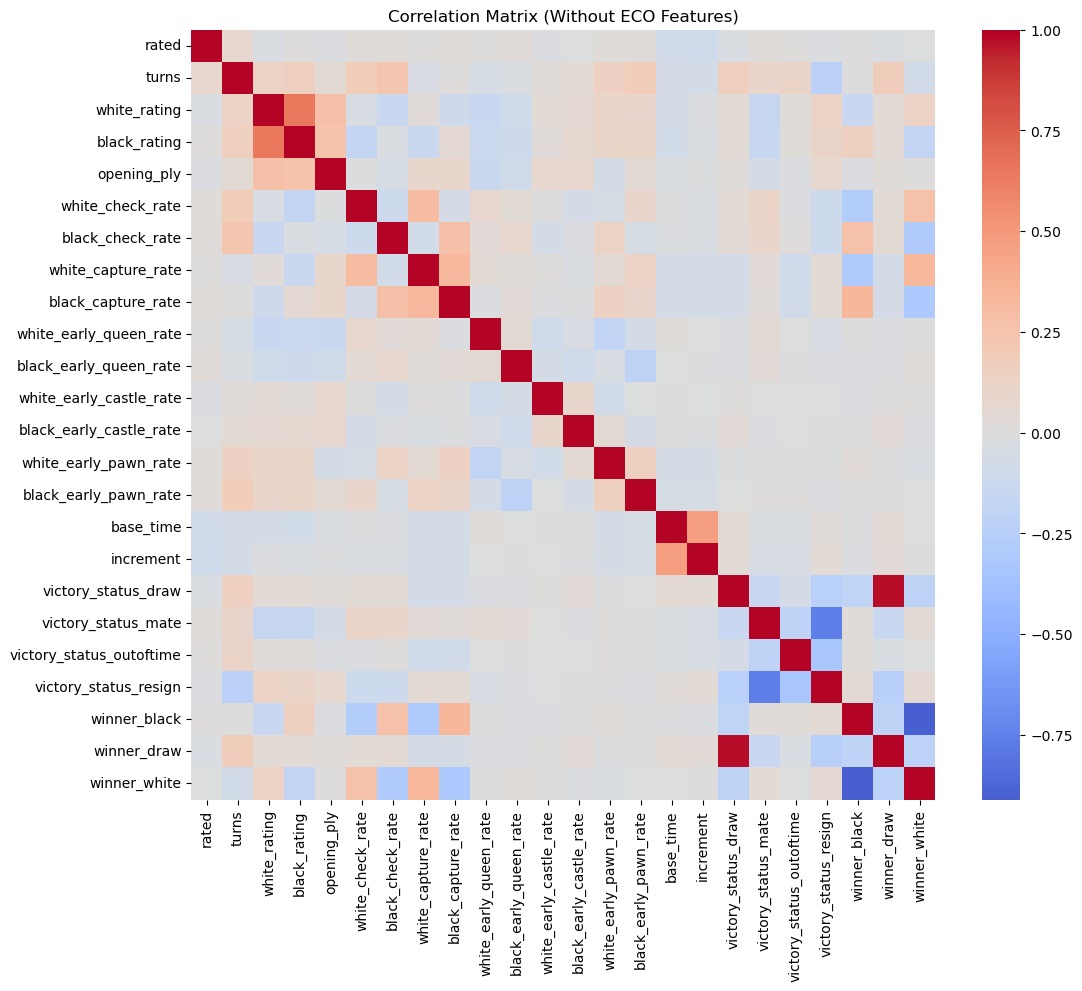

In [12]:
# Feature Engineering: Correlation Matrix with new features (No ECO)
df_corr = df_clean.loc[:, ~df_clean.columns.str.startswith("opening_eco")]
corr_matrix = df_corr.corr()
plt.figure(figsize=(12,10))
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix (Without ECO Features)")
plt.show()

SECTION: MODELLING

In [13]:
# StandardScaling the data for modeling
from sklearn.preprocessing import StandardScaler


In [39]:
# Modeling: Linear Regression Function
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error

def linear_regression(X, y):
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Identify binary columns (0/1 or boolean)
    binary_cols = [col for col in X.columns if set(X[col].dropna().unique()).issubset({0,1})]
    non_binary_cols = [col for col in X.columns if col not in binary_cols]

    # Scale only non-binary features
    scaler = StandardScaler()
    X_train_scaled_part = scaler.fit_transform(X_train[non_binary_cols])
    X_test_scaled_part = scaler.transform(X_test[non_binary_cols])

    # Recombine scaled and unscaled features WITHOUT resetting index
    X_train_processed = pd.concat(
        [
            pd.DataFrame(X_train_scaled_part, columns=non_binary_cols, index=X_train.index),
            X_train[binary_cols]
        ],
        axis=1
    )
    X_test_processed = pd.concat(
        [
            pd.DataFrame(X_test_scaled_part, columns=non_binary_cols, index=X_test.index),
            X_test[binary_cols]
        ],
        axis=1
    )

    # Linear regression with 3-fold CV
    model = LinearRegression()
    cv_scores = cross_val_score(model, X_train_processed, y_train, cv=3, scoring='r2')
    print("CV R2 scores:", cv_scores)
    print("Mean CV R2:", cv_scores.mean())

    # Fit on full training set and evaluate test R2
    model.fit(X_train_processed, y_train)
    r2_test = model.score(X_test_processed, y_test)
    y_pred = model.predict(X_test_processed)
    mae = mean_absolute_error(y_test, y_pred)
    print("Test R2:", r2_test)
    print("Test MAE:", mae)

    # Statsmodels for t-tests and p-values
    X_sm = sm.add_constant(X_train_processed)
    model_sm = sm.OLS(y_train, X_sm).fit()

    # Combine results
    results = pd.DataFrame({
        "feature": ["intercept"] + list(X_train_processed.columns),
        "coefficient": model_sm.params,
        "t_stat": model_sm.tvalues,
        "p_value": model_sm.pvalues
    }).sort_values("p_value")


    
    print(results)

        # Feature impact (magnitude of coefficients)
    results["abs_coef"] = np.abs(results["coefficient"])

    impact = results.drop("const").sort_values("abs_coef", ascending=False)

    print("\nTop 20 Most Impactful Features:")
    print(impact.head(20))
    return impact

In [40]:
# Features and target
y = df_clean['white_rating']
X = df_clean.drop(columns=['white_rating'])

# Perform linear regression
linear_regression(X,y)

CV R2 scores: [0.5278824  0.51677812 0.51839215]
Mean CV R2: 0.521017558516506
Test R2: 0.5308565119122303
Test MAE: 154.38637677805224
                                     feature  coefficient      t_stat  \
const                              intercept  1028.580038  175.751288   
black_rating                    black_rating   185.038314   95.734594   
winner_white                    winner_white   416.806211   36.192542   
winner_black                    winner_black   316.973368   27.548762   
victory_status_resign  victory_status_resign   247.605457   24.955794   
...                                      ...          ...         ...   
opening_eco_D05              opening_eco_D05     0.586764    0.012660   
opening_eco_A20              opening_eco_A20    -0.318187   -0.012627   
opening_eco_B38              opening_eco_B38     0.808979    0.009864   
opening_eco_A38              opening_eco_A38     0.616805    0.006862   
opening_eco_B98              opening_eco_B98    -0.684916   -

,feature,coefficient,t_stat,p_value,abs_coef
opening_eco_E44,opening_eco_E44,5.930302e+02,2.959336,0.003088,5.930302e+02
opening_eco_E18,opening_eco_E18,4.708379e+02,2.346574,0.018960,4.708379e+02
opening_eco_B75,opening_eco_B75,-4.626435e+02,-3.986948,0.000067,4.626435e+02
opening_eco_E06,opening_eco_E06,4.213691e+02,2.103903,0.035404,4.213691e+02
opening_eco_E42,opening_eco_E42,-4.184809e+02,-2.089540,0.036677,4.184809e+02
...,...,...,...,...,...
opening_eco_D22,opening_eco_D22,-3.081409e-13,-1.105597,0.268919,3.081409e-13
opening_eco_E48,opening_eco_E48,-2.743696e-13,-0.393175,0.694196,2.743696e-13
opening_eco_E33,opening_eco_E33,1.393986e-13,0.195952,0.844651,1.393986e-13
opening_eco_D81,opening_eco_D81,2.060449e-14,0.085309,0.932017,2.060449e-14


CV R2 scores: [0.5278824  0.51677812 0.51839215]
Mean CV R2: 0.521017558516506
Test R2: 0.5308565119122303
Test MAE: 154.38637677805224
                                     feature  coefficient      t_stat  \
const                              intercept  1028.580038  175.751288   
black_rating                    black_rating   185.038314   95.734594   
winner_white                    winner_white   416.806211   36.192542   
winner_black                    winner_black   316.973368   27.548762   
victory_status_resign  victory_status_resign   247.605457   24.955794   
...                                      ...          ...         ...   
opening_eco_D05              opening_eco_D05     0.586764    0.012660   
opening_eco_A20              opening_eco_A20    -0.318187   -0.012627   
opening_eco_B38              opening_eco_B38     0.808979    0.009864   
opening_eco_A38              opening_eco_A38     0.616805    0.006862   
opening_eco_B98              opening_eco_B98    -0.684916   -

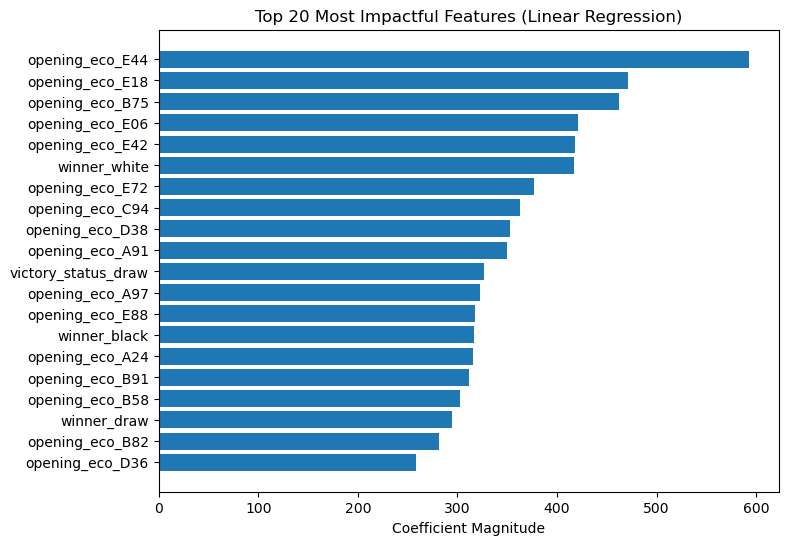

In [43]:
y = df_clean['white_rating']
X = df_clean.drop(columns=['white_rating'])
impact = linear_regression(X, y)
top_features = impact.head(20)

plt.figure(figsize=(8,6))
plt.barh(top_features["feature"], top_features["abs_coef"])
plt.gca().invert_yaxis()
plt.title("Top 20 Most Impactful Features (Linear Regression)")
plt.xlabel("Coefficient Magnitude")
plt.show()

In [27]:
from sklearn.model_selection import  GridSearchCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score, mean_absolute_error

def kernel_ridge_regression(X, y):
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Identify binary columns (0/1 or boolean)
    binary_cols = [col for col in X.columns if set(X[col].dropna().unique()).issubset({0,1})]
    non_binary_cols = [col for col in X.columns if col not in binary_cols]

    # Scale only non-binary features
    scaler = StandardScaler()
    X_train_scaled_part = scaler.fit_transform(X_train[non_binary_cols])
    X_test_scaled_part = scaler.transform(X_test[non_binary_cols])

    # Recombine scaled and unscaled features
    X_train_processed = pd.concat(
        [
            pd.DataFrame(X_train_scaled_part, columns=non_binary_cols, index=X_train.index),
            X_train[binary_cols]
        ],
        axis=1
    )
    X_test_processed = pd.concat(
        [
            pd.DataFrame(X_test_scaled_part, columns=non_binary_cols, index=X_test.index),
            X_test[binary_cols]
        ],
        axis=1
    )

    # Kernel Ridge Regression with hyperparameter tuning
    param_grid = {
        "alpha": [1e-3, 1e-2, 1e-1, 1, 10],
        "gamma": [1e-4, 1e-3, 1e-2, 1e-1, 1]
    }
    krr = KernelRidge(kernel="rbf")
    grid = GridSearchCV(krr, param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X_train_processed, y_train)

    print("Best hyperparameters:", grid.best_params_)
    print("Best CV R2:", grid.best_score_)

    # Evaluate on test set
    y_pred = grid.predict(X_test_processed)
    r2_test = r2_score(y_test, y_pred)
    mae_test = mean_absolute_error(y_test, y_pred)
    print("Test R2:", r2_test)
    print("Test MAE:", mae_test)
    
    return grid, X_train_processed, X_test_processed, y_train, y_test, y_pred

In [22]:
kernel_ridge_regression(X,y)

Best hyperparameters: {'alpha': 0.1, 'gamma': 0.01}
Best CV R2: 0.5616314488643624
Test R2: 0.5737971443141922
Test MAE: 147.6000911084534


(GridSearchCV(cv=3, estimator=KernelRidge(kernel='rbf'), n_jobs=-1,
              param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10],
                          'gamma': [0.001, 0.01, 0.1, 1, 10]},
              scoring='r2'),
           turns  black_rating  opening_ply  white_check_rate  \
 15637  0.090429      1.090355    -0.661446          0.613903   
 12085 -0.207122     -0.213693     0.407248         -0.877025   
 7945   2.113778      1.364003    -1.017677         -0.515588   
 14227  0.477246      0.698465     2.188404         -0.877025   
 4472   0.774797      0.380899     0.763479          0.493943   
 ...         ...           ...          ...               ...   
 11284  0.566511      0.769411     0.051017         -0.877025   
 11964  0.239205      0.860627    -0.305214          0.505865   
 5390   0.715287      0.083603     0.407248          1.087492   
 860    1.042593     -0.169774    -1.017677          1.359367   
 15795  0.536756     -0.801528    -0.661446          1.236695  

SECTION: PCA AND THEN MORE MODELLING

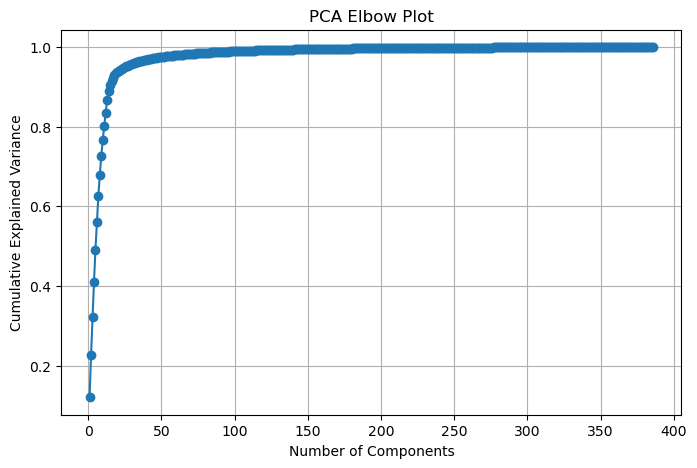

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Separate features from target
X = df_clean.drop(columns=["white_rating"])

# Identify binary columns (only 0 and 1)
binary_cols = [col for col in X.columns if set(X[col].unique()).issubset({0,1})]
non_binary_cols = [col for col in X.columns if col not in binary_cols]

# Scale only non-binary columns
scaler = StandardScaler()
X_scaled_part = scaler.fit_transform(X[non_binary_cols])

# Recombine scaled non-binary and original binary features
X_processed = pd.concat(
    [
        pd.DataFrame(X_scaled_part, columns=non_binary_cols, index=X.index),
        X[binary_cols].reset_index(drop=True)
    ],
    axis=1
)

# PCA
pca = PCA()
pca.fit(X_processed)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Elbow Plot")
plt.grid(True)
plt.show()

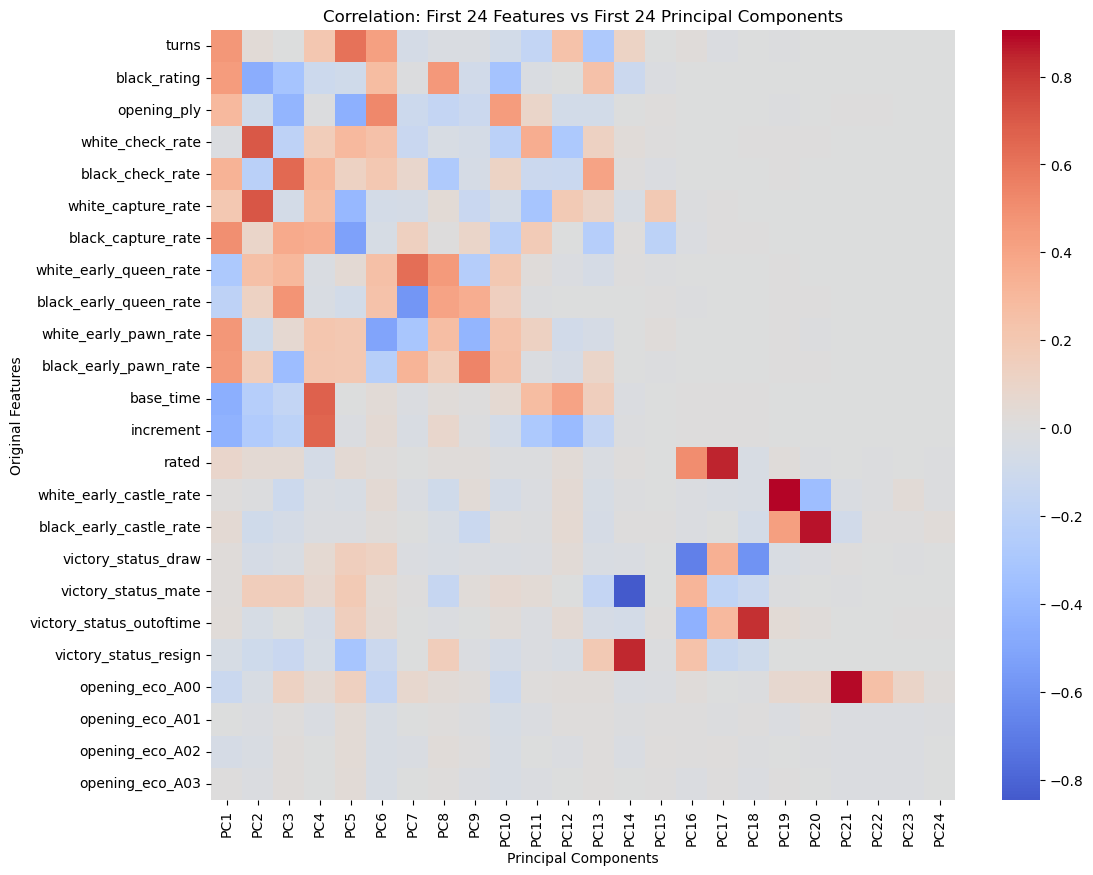

In [23]:
X_pca = pca.transform(X_processed)
features_24 = X_processed.iloc[:, :24]
pcs_24 = pd.DataFrame(X_pca[:, :24], columns=[f"PC{i+1}" for i in range(24)])
corr_matrix = pd.concat([features_24, pcs_24], axis=1).corr()

# Only keep feature vs PC correlations
corr_matrix = corr_matrix.loc[features_24.columns, pcs_24.columns]
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation: First 24 Features vs First 24 Principal Components")
plt.xlabel("Principal Components")
plt.ylabel("Original Features")
plt.show()

In [25]:
# Apply Linear Regression to PCA, using n = 24 components based on elbow plot

# Features and target
y = df_clean['white_rating']
X = pcs_24

linear_regression(X,y)

CV R2 scores: [0.53643581 0.52381328 0.52348386]
Mean CV R2: 0.527910981932596
Test R2: 0.5309132403711927
Test MAE: 153.41762906120525
         feature  coefficient      t_stat        p_value
const  intercept  1602.303393  961.824770   0.000000e+00
PC1          PC1    83.980356   50.378111   0.000000e+00
PC3          PC3  -120.236814  -72.158310   0.000000e+00
PC8          PC8    90.585915   54.363715   0.000000e+00
PC13        PC13    57.490844   34.502928  5.378073e-251
PC2          PC2   -56.757827  -34.058394  7.378465e-245
PC6          PC6    54.503906   32.711194  1.124505e-226
PC11        PC11   -39.928037  -23.956469  1.811089e-124
PC9          PC9   -36.833063  -22.104238  1.502086e-106
PC10        PC10   -35.918955  -21.557990  1.602925e-101
PC7          PC7   -34.289260  -20.578907   8.364151e-93
PC4          PC4   -32.372054  -19.421896   5.400263e-83
PC15        PC15   -18.876672  -11.329595   1.239566e-29
PC5          PC5   -14.454757   -8.674722   4.570961e-18
PC14     

In [28]:
kernel_ridge_regression(X,y)

Best hyperparameters: {'alpha': 0.01, 'gamma': 0.001}
Best CV R2: 0.5494840705522588
Test R2: 0.5640622250272098
Test MAE: 148.90471740477102


(GridSearchCV(cv=3, estimator=KernelRidge(kernel='rbf'), n_jobs=-1,
              param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10],
                          'gamma': [0.0001, 0.001, 0.01, 0.1, 1]},
              scoring='r2'),
             PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
 15637  1.050748 -0.229967  0.370198  0.291954 -0.030661 -0.102001  0.577305   
 12085  1.176574 -0.225092  0.067572  0.396058 -0.719419 -0.707325  1.036369   
 7945   0.444841 -0.964430 -0.192954  0.022869  1.101153  0.742534  0.271053   
 14227  0.336011 -1.231356 -0.150220  0.306399 -1.246338  2.112454  0.254212   
 4472   0.307100  0.309507 -0.737260 -0.007705  0.289375  0.469350 -0.866548   
 ...         ...       ...       ...       ...       ...       ...       ...   
 11284  0.519430 -0.719390 -0.546191  0.194181  0.069144 -0.687900 -0.556403   
 11964  0.754374  0.228060 -0.757137 -0.073455  0.948595 -0.489299  0.006718   
 5390   0.614504  1.285002 -0.734185  0.197656 -0.4394

In [31]:
# XGBoost

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# Separate features and target
X = df_clean.drop(columns=["white_rating"])
y = df_clean["white_rating"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Base model
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
param_dist = {
    "n_estimators": [600, 800, 1000],
    "max_depth": [3, 5, 7, 9, 12, 15, 18],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1, 2],
    "reg_lambda": [1, 3, 5, 7]
}

# Randomized hyperparameter search
search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="r2",
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best Parameters:")
print(search.best_params_)
print("Best CV R2:", search.best_score_)

# Best model
best_model = search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test R2:", r2)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'subsample': 0.85, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 800, 'max_depth': 15, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV R2: 0.5857054988543192
Test MAE: 137.94760131835938
Test R2: 0.6141813397407532


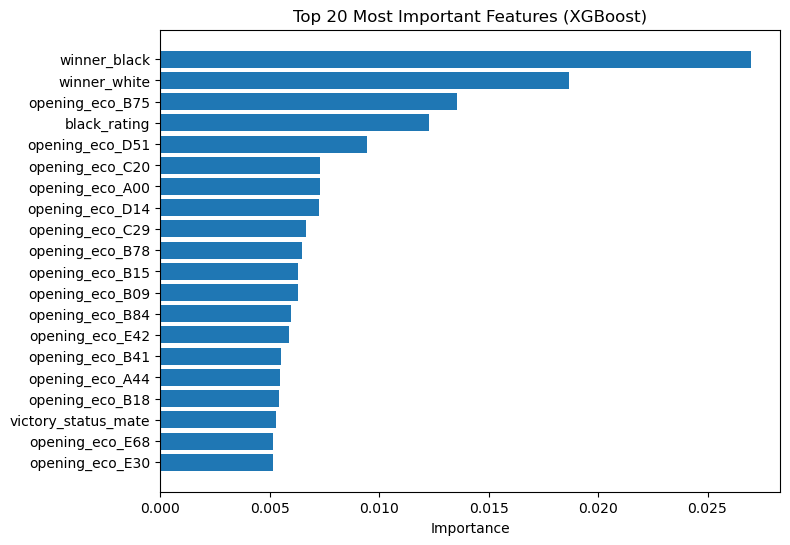

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

importance = best_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values("importance", ascending=False)

# Top 20 features
top_features = importance_df.head(20)

plt.figure(figsize=(8,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Most Important Features (XGBoost)")
plt.xlabel("Importance")
plt.show()